# TASK 1. PROJECT OVERVIEW

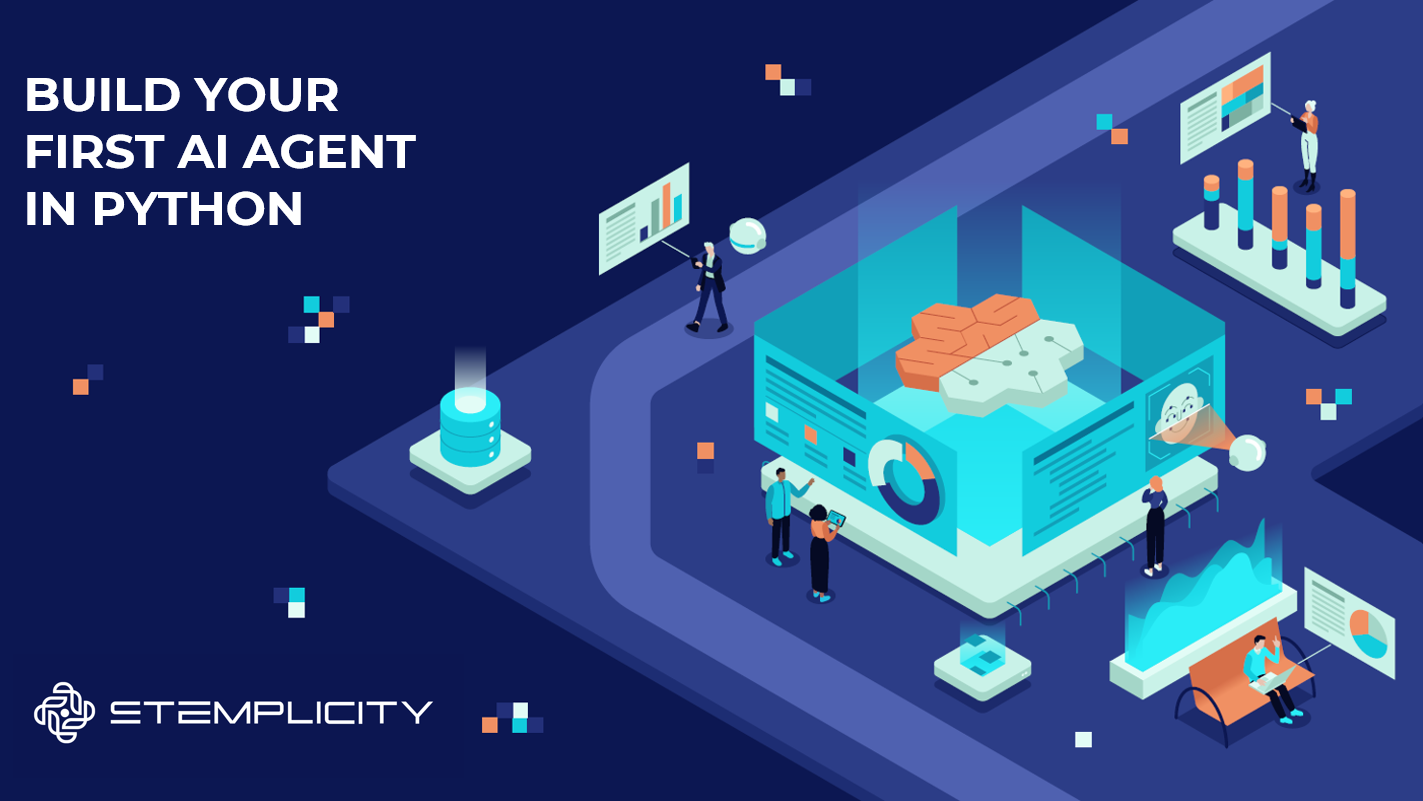

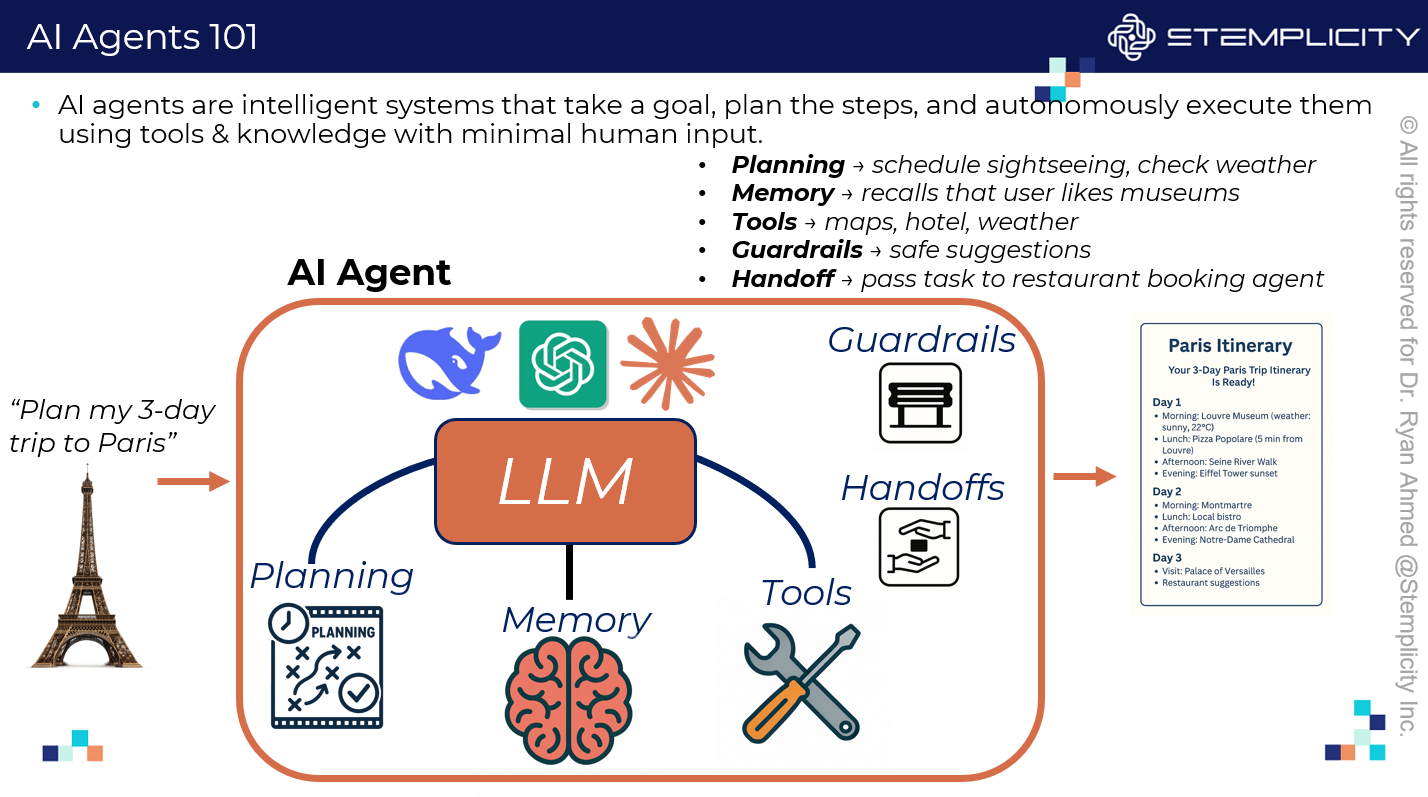

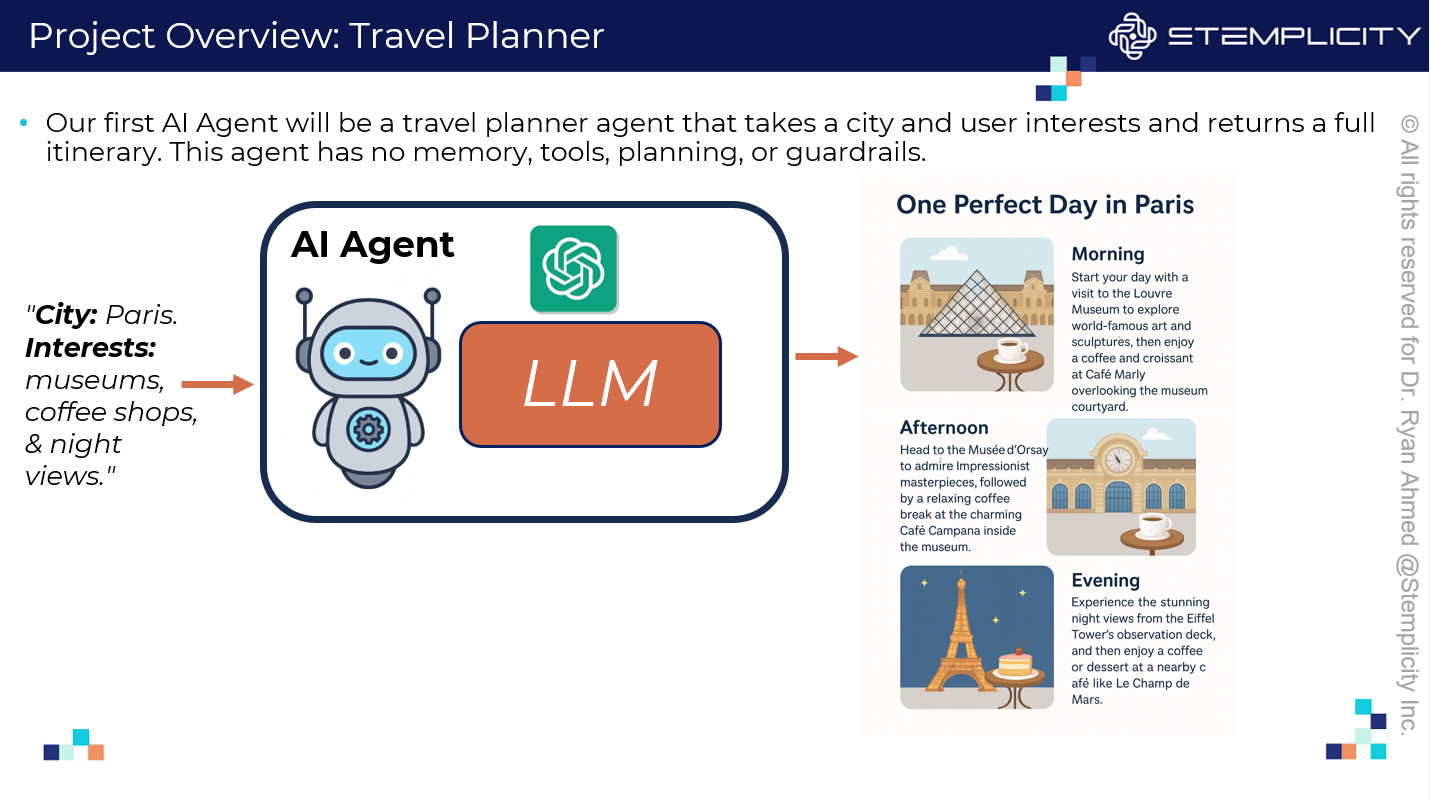

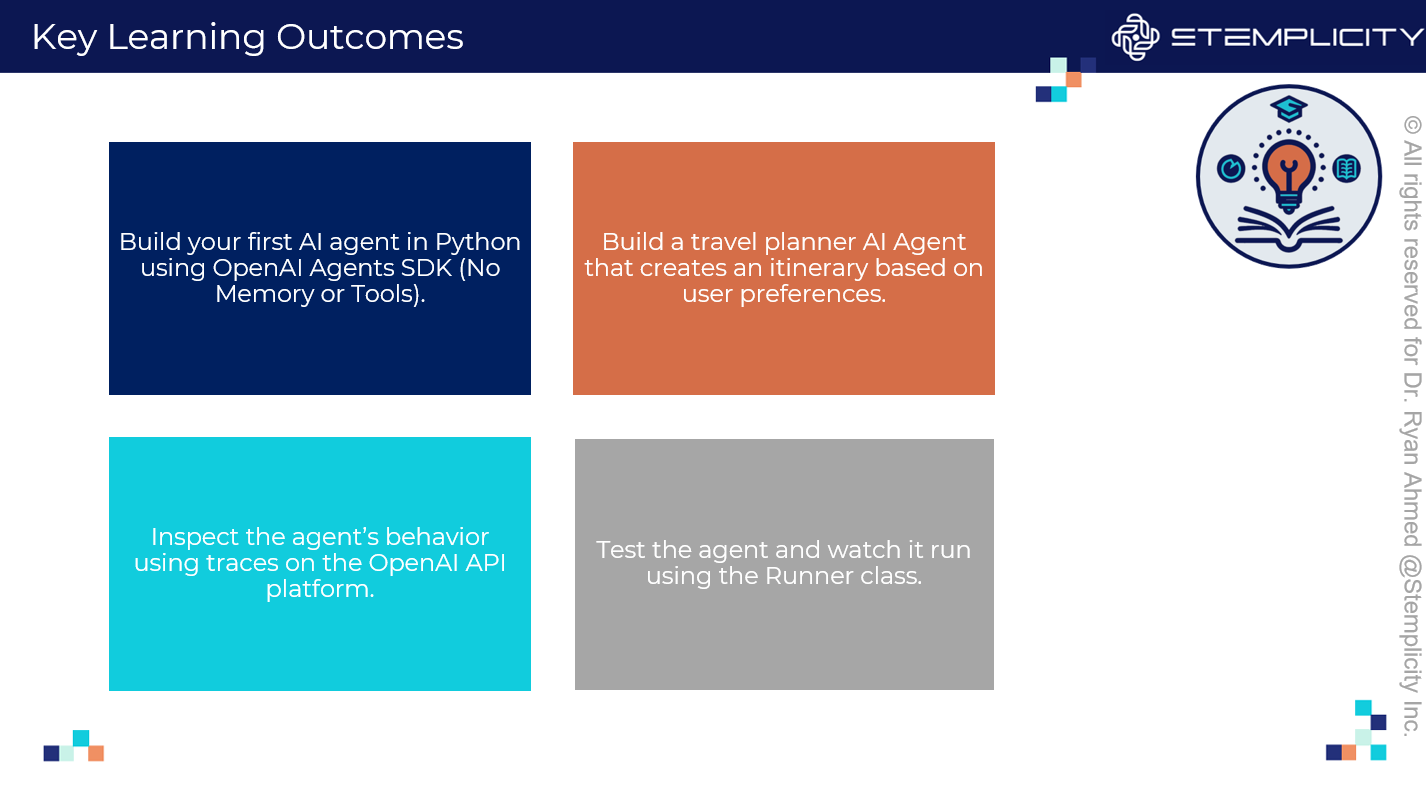

# TASK 2. CONFIGURE OPENAI API & AGENTS SDK

Before we can build our first AI agent, we need two things:

1. The `openai-agents` library installed.  
2. Your secret OpenAI API key to communicate with the AI models.

> **Security tip﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿**﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿Store keys securely in a `.env` file. Make sure you have a file named `.env` in the same directory as this notebook with your key:
>
> ```dotenv
> OPENAI_API_KEY=sk-YourSecretOpenAIKeyGoesHereXXXXXXXXXXXXX
> ```

Let's run the cells below to install the necessary packages and load your API key.

- **You can access the OpenAI API here: https://openai.com/api/**

In [1]:
# Uninstall openai-agents - if you have it installed
# Note that an SDK stands for "software development kit" which is a toolbox for building software for a specific platform or service.
!pip uninstall -y openai-agents

Found existing installation: openai-agents 0.2.2
Uninstalling openai-agents-0.2.2:
  Successfully uninstalled openai-agents-0.2.2


In [2]:
# Install the specific version of openai-agents
!pip install --no-cache-dir openai-agents==0.2.2


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Install required Python packages:
# langchain-openai==0.2.1: a specific version of LangChain﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s OpenAI integration library
# LangChain is a framework that makes it easier to build applications powered by large language models 
# It provides tools to connect to AI models, store context, and chain multiple steps together.
!pip install python-dotenv langchain-openai==0.2.1

# Upgrade the Pydantic library (used for validating and organizing data)  
# This ensures compatibility with the installed packages above  
!pip install --upgrade pydantic


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Let's import "os" module, which stands for "Operating System"
# The os module in Python provides a way to interact with the operating system for things like:
# (1) accessing Environment Variables
# (2) Creating, renaming, and deleting files/folders.
import os
from openai import OpenAI
from IPython.display import display, Markdown

# This will be used to load the API key from the .env file
from dotenv import load_dotenv
load_dotenv(override=True)

# Get the OpenAI API keys from environment variables
openai_api_key = os.getenv("OPENAI_API_KEY")



# Let's configure the OpenAI Client using our key
#openai_client = OpenAI(api_key = openai_api_key)
openai_client = OpenAI(
    base_url=os.getenv("OPENAI_BASE_URL"),
    api_key="Bearer "+os.getenv("OPENAI_API_KEY")
)
print("OpenAI client successfully configured.")

# Let's view the first few characters in the key
print(openai_api_key[:5])

OpenAI client successfully configured.
8f7e2


In [2]:
# A Function used to show the given text using Markdown formatting in a Jupyter notebook
def print_markdown(text):
    """Displays text as Markdown in Jupyter."""
    display(Markdown(text))

# TASK 3. BUILD & RUN YOUR FIRST AI AGENT USING OPENAI AGENT SDK

It's time to build our first agent! We will use the `Agent` class from the `openai-agents` library.

Creating an agent is like hiring an employee. You need to provide a **job description**. The key parameters are:

* **client**: The OpenAI client we just configured. This is the agent's connection to the AI brain.  
* **name**: A simple name to identify your agent (e.g., "Tavel Planner").  
* **instructions**: The most important part. It's the "system prompt" or the detailed job description for the agent. This tells the agent who to be and what to do.  
* **model**: The specific OpenAI model the agent will use (e.g., `gpt-4o-mini` is fast and cost﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿effective or use the latest `gpt-5` for enhanced results and longer context).

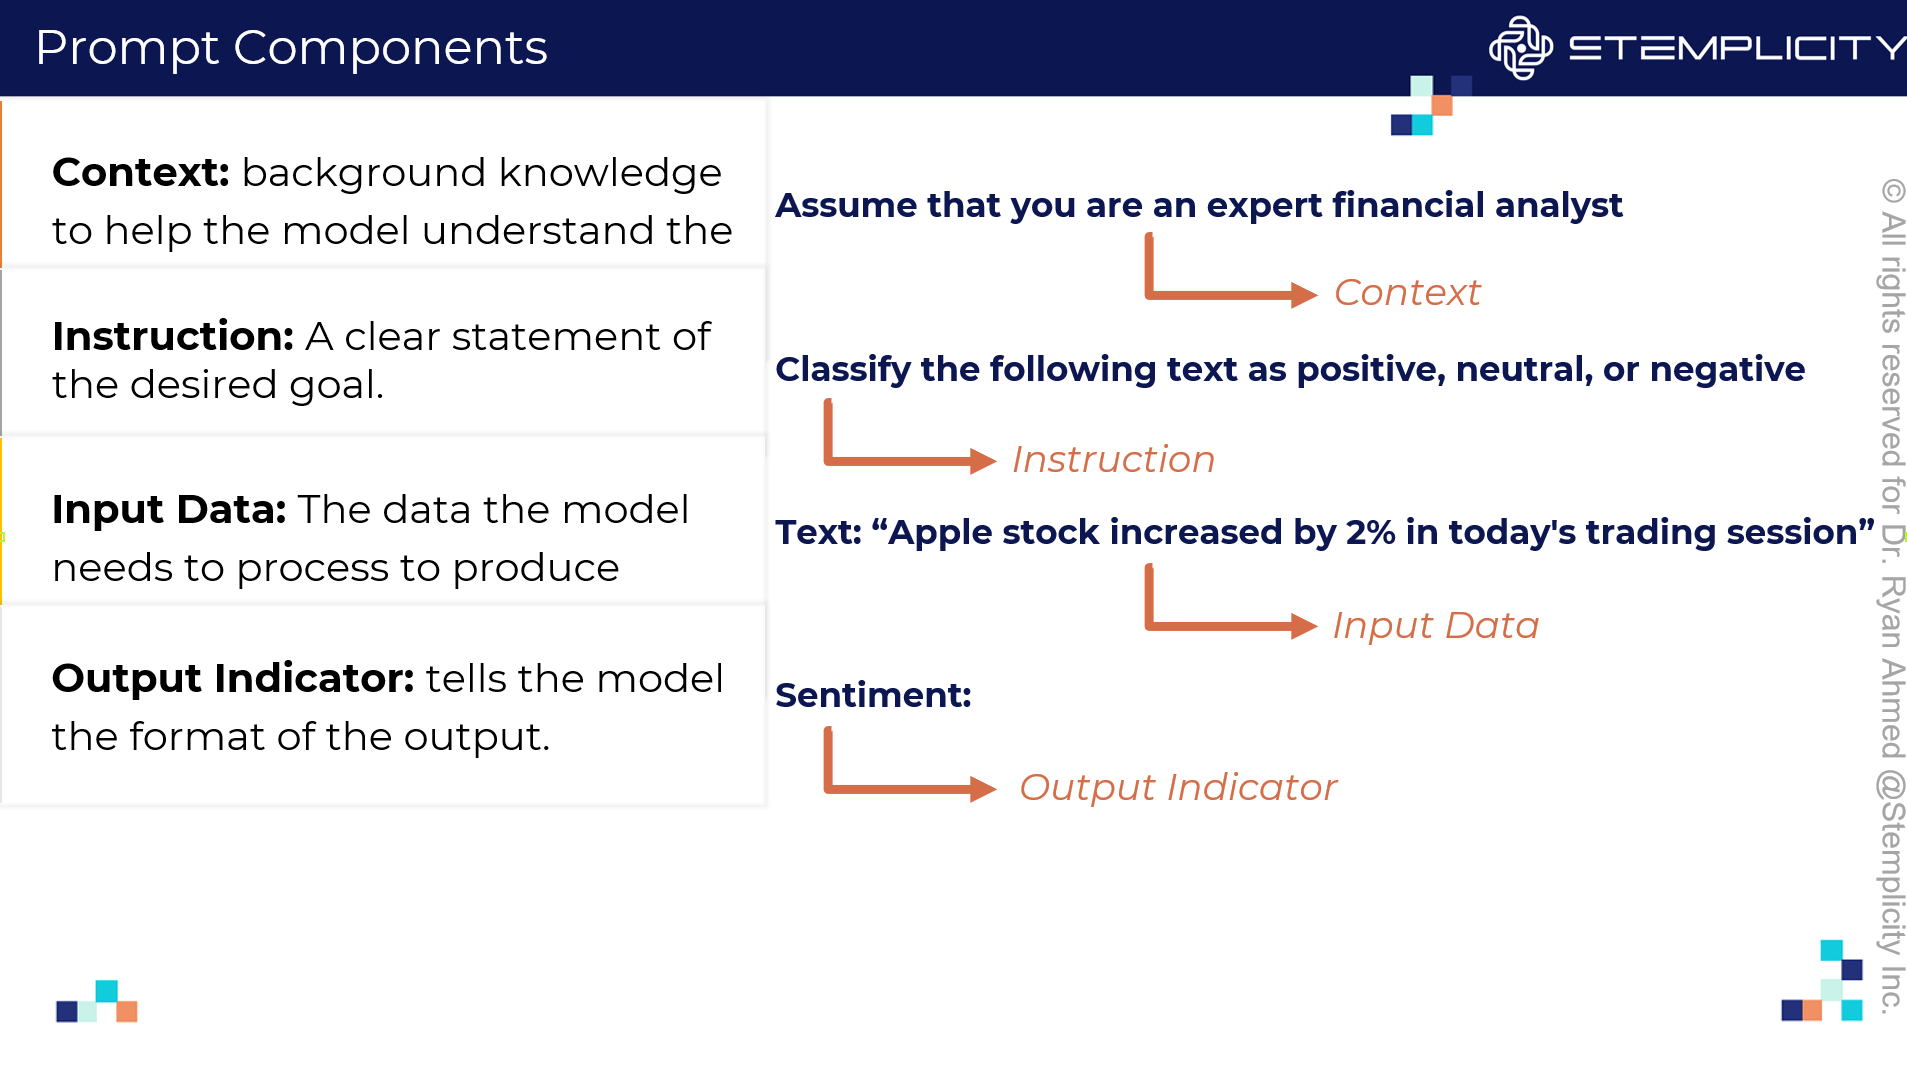

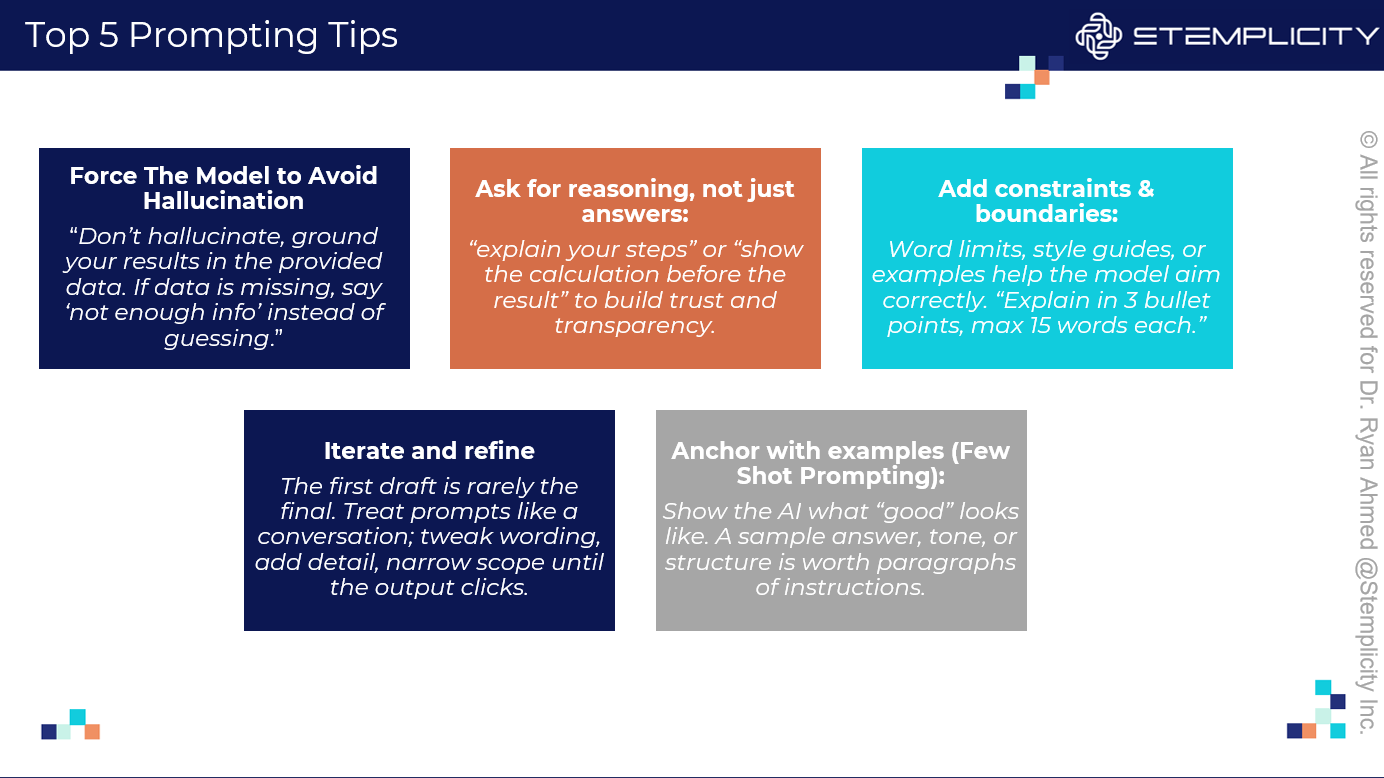

In [3]:
# Import the OpenAI API client
from openai import OpenAI 

# Import the Agent class to create and manage AI agents
from agents import Agent

# Define the instructions for the fact-checker AI Agent
trip_planner_instructions = """
Context:
You are a friendly travel planner who designs simple one-day itineraries.

Instructions:
When given a city and a list of interests, create a realistic one-day plan with:
- A morning activity
- An afternoon activity
- An evening activity

Make your suggestions:
- Specific and easy to understand
- Safe and tourist-friendly
- Based only in the city mentioned

If the interests are unclear, choose popular attractions most visitors enjoy.

Input:
You will receive a short description that includes:
- The city name
- The traveler﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s interests (e.g., museums, food, nightlife)

Output:
Respond with:
1. A clear title for the day (e.g., "One Perfect Day in Paris").
2. A bullet list with three sections:
   - Morning: ...
   - Afternoon: ...
   - Evening: ...
Each section should be 1﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿2 short sentences.
"""

In [4]:
# Create a new agent called "Trip Planner"
trip_planner_agent = Agent(
    name = "Trip Planner",                 # Name of the agent
    instructions = trip_planner_instructions,  # The rules and behavior for the agent
    model = "gpt-3.5-turbo"                 # The AI model (LLM) to use
)

# Print a confirmation message that the agent was created
print(f"Agent '{trip_planner_agent.name}' created successfully!")

Agent 'Trip Planner' created successfully!


Let's put our `Trip Planner` to work! We'll use the `Runner.run()` method to send it a statement to fact-check. The agent will analyze the statement and return its verdict along with a brief explanation.

In [5]:
# Import the Runner class, which is used to run an agent and get its output
from agents import Runner
from dotenv import load_dotenv

load_dotenv(override=True)

# A request we want the Trip Planner agent to work with
itinerary_request = "City: Paris. Interests: museums, coffee shops, and night views."

# Display the request we're going to check (in markdown format for nicer formatting)
print_markdown(f"Asking the Trip Planner Agent to design a day for: '{itinerary_request}'")

# Run the Trip Planner agent on the input request
# 'await' is used because running the agent is an asynchronous operation (it might take time)
response = await Runner.run(
    starting_agent = trip_planner_agent,   # The agent we created earlier
    input = itinerary_request              # The statement we want it to plan a trip for
)

print_markdown(os.getenv("OPENAI_API_KEY")[:5])

# Display the agent's response
print_markdown("\n ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Trip Planner Agent's Response:\n")  # Title for the output
print_markdown(response.final_output)                    # Shows the full itinerary

Asking the Trip Planner Agent to design a day for: 'City: Paris. Interests: museums, coffee shops, and night views.'

Error getting response: <!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Error</title>
</head>
<body>
<pre>Cannot POST /labs-ai-proxy/rest/openai/chatgpt-4o/v1/chat/completions/responses</pre>
<script>(function(){function c(){var b=a.contentDocument||a.contentWindow.document;if(b){var d=b.createElement('script');d.innerHTML="window.__CF$cv$params={r:'a0a5b0eebec23a33',t:'MTc4MTIzNDEyNw=='};var a=document.createElement('script');a.src='/cdn-cgi/challenge-platform/scripts/jsd/main.js';document.getElementsByTagName('head')[0].appendChild(a);";b.getElementsByTagName('head')[0].appendChild(d)}}if(document.body){var a=document.createElement('iframe');a.height=1;a.width=1;a.style.position='absolute';a.style.top=0;a.style.left=0;a.style.border='none';a.style.visibility='hidden';document.body.appendChild(a);if('loading'!==document.readyState)c();else if(window.addEventListener)document.addEventListener('DOMContentLoaded',c);else{var e=document.onreadystatechange||function()

NotFoundError: <!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8">
<title>Error</title>
</head>
<body>
<pre>Cannot POST /labs-ai-proxy/rest/openai/chatgpt-4o/v1/chat/completions/responses</pre>
<script>(function(){function c(){var b=a.contentDocument||a.contentWindow.document;if(b){var d=b.createElement('script');d.innerHTML="window.__CF$cv$params={r:'a0a5b0eebec23a33',t:'MTc4MTIzNDEyNw=='};var a=document.createElement('script');a.src='/cdn-cgi/challenge-platform/scripts/jsd/main.js';document.getElementsByTagName('head')[0].appendChild(a);";b.getElementsByTagName('head')[0].appendChild(d)}}if(document.body){var a=document.createElement('iframe');a.height=1;a.width=1;a.style.position='absolute';a.style.top=0;a.style.left=0;a.style.border='none';a.style.visibility='hidden';document.body.appendChild(a);if('loading'!==document.readyState)c();else if(window.addEventListener)document.addEventListener('DOMContentLoaded',c);else{var e=document.onreadystatechange||function(){};docume

**PRACTICE OPPORTUNITY:** 
- **Now it's your turn to experiment with OpenAI API Agents SDK; perform the following tasks:**
   - **Change the text inside the `itinerary_request` variable. Try a different city and interest and examine how the AI agent responds!**
   - **Try a different AI model, change the model from `model="gpt-4o-mini"` to `model="gpt-5"`**

## TASK 4. CHECK IF THE AI AGENT CAN RECALL INFORMATION (NO MEMORY) & CHECK TRACES

In [ ]:
check_recall_statement = "What did we discuss in the last message?"

response = await Runner.run(starting_agent = trip_planner_agent, input = check_recall_statement)
print_markdown("\n﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Agent's Response:\n")
print_markdown(response.final_output)

- **Note: You can monitor what the Agent did through traces, available in the OpenAI platform when you log in to your account.**
- **Link: https://platform.openai.com/logs/**

**OpenAI Tokenizer: https://platform.openai.com/tokenizer**

**PRACTICE OPPORTUNITY:**  
- **Create a new AI agent named `Mental Health Coach` that generates a short, supportive wellbeing tip (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿200 characters) based on a user﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s mood using OpenAI Agents SDK. The tip should include at least one emoji and remain strictly within general self-care (e.g., breathing, rest, journaling); no medical or crisis advice.**  
    - **1. Set Up Instructions: Define `Mental Health Coach`﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s purpose and personality (warm, calm, reassuring), configure it to use the latest `gpt-5-mini` model, and instruct it to avoid medical or diagnostic advice.**  
    - **2. Choose a Mood Input: For example use "I'm feeling overwhelmed today."**  
    - **3. Run the Agent: Use `Runner.run()` to execute the agent and print the generated wellbeing tip. Use traces to track the Agent behaviour and list the number of input and output tokens used.**


# PRACTICE OPPORTUNITY SOLUTIONS

**PRACTICE OPPORTUNITY SOLUTION:** 
- **Now it's your turn to experiment with OpenAI API Agents SDK; perform the following tasks:**
   - **Change the text inside the `itinerary_request` variable. Try a different city and interest and examine how the AI agent responds!**
   - **Try a different AI model, change the model from `model="gpt-4o-mini"` to `model="gpt-5"`**

**OpenAI Models: https://platform.openai.com/docs/models**

In [ ]:
# Create a new agent called "Trip Planner"
trip_planner_agent = Agent(
    name = "Trip Planner",                 # Name of the agent
    instructions = trip_planner_instructions,  # The rules and behavior for the agent
    model = "gpt-5"                 # The AI model (LLM) to use
)

# Print a confirmation message that the agent was created
print(f"Agent '{trip_planner_agent.name}' created successfully!")

In [ ]:
# Import the Runner class, which is used to run an agent and get its output
from agents import Runner

# A request we want the Trip Planner agent to work with
itinerary_request = "City: Cairo. Interests: history and authentic food"

# Display the request we're going to check (in markdown format for nicer formatting)
print_markdown(f"Asking the Trip Planner Agent to design a day for: '{itinerary_request}'")

# Run the Trip Planner agent on the input request
# 'await' is used because running the agent is an asynchronous operation (it might take time)
response = await Runner.run(
    starting_agent = trip_planner_agent,   # The agent we created earlier
    input = itinerary_request              # The statement we want it to plan a trip for
)

# Display the agent's response
print_markdown("\n﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Trip Planner Agent's Response:\n")  # Title for the output
print_markdown(response.final_output)                    # Shows the full itinerary

**PRACTICE OPPORTUNITY SOLUTION:**  
- **Create a new AI agent named `Mental Health Coach` that generates a short, supportive wellbeing tip (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿200 characters) based on a user﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s mood using OpenAI Agents SDK. The tip should include at least one emoji and remain strictly within general self-care (e.g., breathing, rest, journaling); no medical or crisis advice.**  
    - **1. Set Up Instructions: Define `Mental Health Coach`﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿s purpose and personality (warm, calm, reassuring), configure it to use the latest `gpt-5-mini` model, and instruct it to avoid medical or diagnostic advice.**  
    - **2. Choose a Mood Input: For example use "I'm feeling overwhelmed today."**  
    - **3. Run the Agent: Use `Runner.run()` to execute the agent and print the generated wellbeing tip. Use traces to track the Agent behaviour and list the number of input and output tokens used.**


In [ ]:
mental_health_instructions = """
Instruction:
Write a short, supportive wellbeing tip (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿200 characters) in response to the user's mood. 
The tip must include one emoji and stay within general self-care (e.g., breathing, rest, journaling, talking to a friend). 
Do NOT give medical, diagnostic, or crisis advice.

Context:
You are **Mental Health Coach**, a warm, calm, non-judgmental companion who offers gentle, everyday wellbeing suggestions. 
You avoid mentioning medication, diagnoses, or specific treatment plans. 
If the user sounds very distressed, gently encourage them to seek support from a trusted person or a qualified professional.

Input:
A short message describing how the user feels.

Output:
A single wellbeing tip (﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿200 characters) tailored to the mood, written in a kind and encouraging tone, 
containing at least one relevant emoji and no more than one sentence.
"""


In [ ]:
# Let's define the Agent
mental_health_agent = Agent(
    name = "Mental Health Coach",
    instructions = mental_health_instructions,
    model = "gpt-5-mini")

print(f"Agent '{mental_health_agent.name}' created successfully!")


In [ ]:
# Let's run the agent and test it out!
mood = "I'm feeling overwhelmed today."
print_markdown(f"\nAsking Mental Health Coach for a tip about: '{mood}'")

mh_response = await Runner.run(starting_agent=mental_health_agent, input=mood)

print_markdown("\n﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Mental Health Coach's Tip:\n")
print_markdown(mh_response.final_output)

# (Optional) If you want, you can also inspect mh_response.traces or token usage here, 
# depending on how you're visualizing traces in your notebook / platform.


- **Would love to connect with everyone on LinkedIn: www.linkedin.com/in/dr-ryan-ahmed**

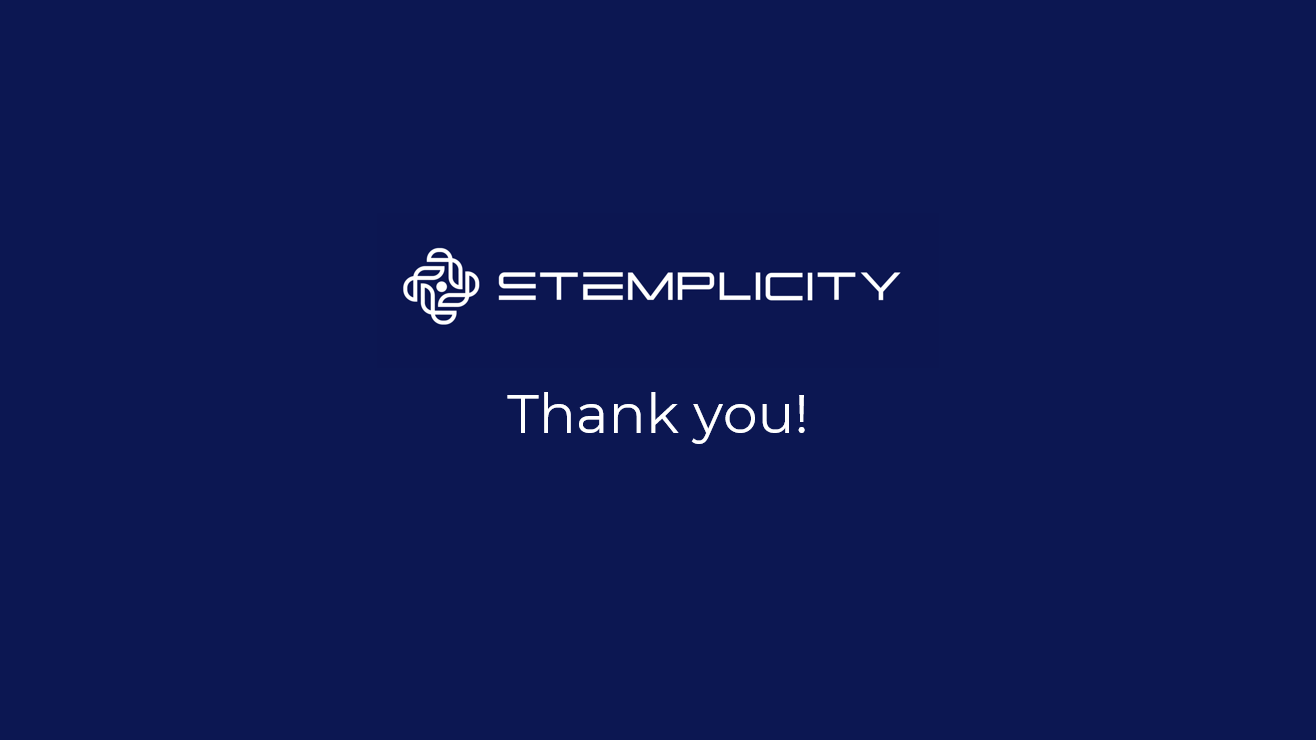